# NLP

NLP, ou Processamento de Linguagem Natural, e uma area da ciencia de dados que estuda como transformar textos em informacao estruturada. Com essas tecnicas, conseguimos analisar noticias, identificar temas, contar palavras, comparar documentos e preparar dados textuais para modelos de aprendizado de maquina.

In [55]:
import json
from pathlib import Path

import pandas as pd

noticias = []

df = pd.read_csv('data/noticias_agencia_minas.csv')

print(f"Antes: {len(df)} noticias")

df = df.drop_duplicates(subset="url").reset_index(drop=True)

print(f"Depois: {len(df)} noticias")

df.head()

Antes: 323 noticias
Depois: 323 noticias


,titulo,subtitulo,descricao,temas,data,ano_mes,ano,mes,hora,turno,n_temas,tamanho_texto,n_palavras_titulo,n_relacionadas,url
0,Minas promove capacitação de clubes de futebol...,Fale Agora será apresentado em times femininos...,Em continuidade à propagação e divulgação do P...,"['Social', 'Esportes']",2024-04-27 12:20:00-03:00,2024-04,2024,4,12,Tarde,2,623,16,4,https://www.agenciaminas.mg.gov.br/noticia/min...
1,Minas Gerais fecha primeiro bloco dos Jogos Es...,"Competição acontece em Uberlândia, no Triângul...",A delegação de Minas Gerais encerrou o primeir...,"['Social', 'Esportes']",2025-10-14 15:20:00-03:00,2025-10,2025,10,15,Tarde,2,684,12,4,https://www.agenciaminas.mg.gov.br/noticia/min...
2,Estudantes de BH vão carregar bandeiras de Bra...,"Ao todo, 26 alunos da Escola Estadual Tomás Br...",Esta terça-feira (2/7) é de expectativa para 2...,"['Educação', 'Esportes']",2019-07-02 17:02:00-03:00,2019-07,2019,7,17,Tarde,2,425,12,4,https://www.agenciaminas.mg.gov.br/noticia/est...
3,Governo publica edital 2019 do programa Bolsa ...,As inscrições terminam no próximo dia 12 de se...,A Secretaria de Estado de Desenvolvimento Soci...,"['Social', 'Esportes']",2019-08-27 14:35:00-03:00,2019-08,2019,8,14,Tarde,2,700,12,4,https://www.agenciaminas.mg.gov.br/noticia/gov...
4,Cruzeiro e Minas Arena assinam acordo mediado ...,Documento foi assinado na tarde desta sexta-fe...,O acordo comercial entre a Minas Arena e o Cru...,['Esportes'],2023-04-28 18:25:00-03:00,2023-04,2023,4,18,Noite,1,463,18,4,https://www.agenciaminas.mg.gov.br/noticia/cru...


## Trabalhando apenas com a descrição

Por enquanto, vamos trabalhar somente com a coluna `descrição`, que contem a descrição de cada noticia. As outras colunas continuam no `DataFrame`, mas vamos deixar elas de lado neste primeiro momento para entender melhor o conteudo textual.

## Passos da analise

Vamos preparar os textos aos poucos:

1. Limpar os textos.
2. Remover palavras muito comuns.
3. Criar uma representacao Bag of Words.
4. Contar palavras frequentes.
5. Transformar textos em numeros para analises posteriores.

## 1. Limpeza basica

Na celula abaixo:

- `wordpunct_tokenize` separa o texto em palavras e pontuacao.
- `texto.lower()` coloca tudo em minusculas.
- `unidecode(texto)` troca letras acentuadas por letras sem acento.
- `token.isalnum()` mantem apenas letras e numeros.
- `" ".join(tokens)` junta os tokens em uma frase limpa.
- `.apply(limpar_texto)` aplica a funcao em todas as noticias.

Exemplo: `"Olá, Senado!"` vira `"ola senado"`.

In [56]:
from nltk.tokenize import wordpunct_tokenize
from unidecode import unidecode


def limpar_descricao(descricao):
    descricao = descricao.lower()
    descricao = unidecode(descricao)
    tokens = wordpunct_tokenize(descricao)
    tokens = [token for token in tokens if token.isalnum()]
    return " ".join(tokens)


df["descricao_limpo"] = df["descricao"].apply(limpar_descricao)

df[["descricao", "descricao_limpo"]].head()

,descricao,descricao_limpo
0,Em continuidade à propagação e divulgação do P...,em continuidade a propagacao e divulgacao do p...
1,A delegação de Minas Gerais encerrou o primeir...,a delegacao de minas gerais encerrou o primeir...
2,Esta terça-feira (2/7) é de expectativa para 2...,esta terca feira 2 7 e de expectativa para 26 ...
3,A Secretaria de Estado de Desenvolvimento Soci...,a secretaria de estado de desenvolvimento soci...
4,O acordo comercial entre a Minas Arena e o Cru...,o acordo comercial entre a minas arena e o cru...


## 2. Removendo stopwords

Stopwords sao palavras muito comuns, como `a`, `o`, `de`, `para` e `que`. Elas aparecem muito, mas geralmente ajudam pouco a entender o tema de um texto.

Na celula abaixo:

- `stopwords.words("portuguese")` carrega stopwords em portugues.
- `texto.split()` separa o texto limpo em palavras.
- `token not in stopwords_pt` remove as palavras muito comuns.
- `.str.join(" ")` junta os tokens restantes em um texto sem stopwords.
- `.apply(remover_stopwords)` aplica a funcao em todas as noticias.

Exemplo: `"o senador falou com a imprensa"` vira `["senador", "falou", "imprensa"]`.

In [57]:
import nltk

from nltk.corpus import stopwords


nltk.download("stopwords", quiet=True)

stopwords_pt = stopwords.words("portuguese")
stopwords_pt = [unidecode(palavra) for palavra in stopwords_pt]
stopwords_pt = set(stopwords_pt)


def remover_stopwords(descricao):
    tokens = descricao.split()
    tokens = [token for token in tokens if token not in stopwords_pt]
    return tokens


df["tokens_sem_stopwords"] = df["descricao_limpo"].apply(remover_stopwords)
df["descricao_sem_stopwords"] = df["tokens_sem_stopwords"].str.join(" ")

df[["descricao_limpo", "tokens_sem_stopwords", "descricao_sem_stopwords"]].head()

,descricao_limpo,tokens_sem_stopwords,descricao_sem_stopwords
0,em continuidade a propagacao e divulgacao do p...,"[continuidade, propagacao, divulgacao, protoco...",continuidade propagacao divulgacao protocolo f...
1,a delegacao de minas gerais encerrou o primeir...,"[delegacao, minas, gerais, encerrou, primeiro,...",delegacao minas gerais encerrou primeiro bloco...
2,esta terca feira 2 7 e de expectativa para 26 ...,"[terca, feira, 2, 7, expectativa, 26, alunos, ...",terca feira 2 7 expectativa 26 alunos ensino f...
3,a secretaria de estado de desenvolvimento soci...,"[secretaria, estado, desenvolvimento, social, ...",secretaria estado desenvolvimento social sedes...
4,o acordo comercial entre a minas arena e o cru...,"[acordo, comercial, minas, arena, cruzeiro, se...",acordo comercial minas arena cruzeiro selado r...


## 3. Bag of Words

No Bag of Words, cada linha representa uma noticia e cada coluna representa uma palavra. O valor indica quantas vezes aquela palavra apareceu na noticia.

Exemplo: `"senador falou senador"` teria `senador = 2` e `falou = 1`.

In [58]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
matriz_bow = vectorizer.fit_transform(df["descricao_sem_stopwords"])

df_bow = pd.DataFrame(
    matriz_bow.toarray(),
    columns=vectorizer.get_feature_names_out()
)

df_bow.head()

,01,04,10,100,11,12,120,13,14,15,...,votacao,vulnerabilidade,vulneraveis,willian,xadrez,xxvii,yago,youtube,zema,zona
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Removendo colunas com numeros

Agora vamos remover qualquer coluna cujo nome tenha pelo menos um numero.

In [59]:
colunas_com_numeros = [col for col in df_bow.columns if any(char.isdigit() for char in col)]

df_bow = df_bow.drop(columns=colunas_com_numeros)

print(f"{len(colunas_com_numeros)} colunas removidas")
df_bow.head()

72 colunas removidas


,abastecimento,aberta,abertas,aberto,abertura,abrangendo,abre,abriu,acaba,acao,...,votacao,vulnerabilidade,vulneraveis,willian,xadrez,xxvii,yago,youtube,zema,zona
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [60]:
df.columns

Index(['titulo', 'subtitulo', 'descricao', 'temas', 'data', 'ano_mes', 'ano',
       'mes', 'hora', 'turno', 'n_temas', 'tamanho_texto', 'n_palavras_titulo',
       'n_relacionadas', 'url', 'descricao_limpo', 'tokens_sem_stopwords',
       'descricao_sem_stopwords'],
      dtype='object')

### Criando o DataFrame final

Agora vamos juntar os metadados das noticias com as colunas do Bag of Words. Para evitar conflito de nomes, as colunas do Bag of Words recebem o prefixo `bow_`.

In [61]:
metadados = df[['titulo', 'subtitulo', 'descricao', 'temas', 'data', 'ano_mes', 'ano',
       'mes', 'hora', 'turno', 'n_temas', 'tamanho_texto', 'n_palavras_titulo',
       'n_relacionadas', 'url']].reset_index(drop=True)
bow_com_prefixo = df_bow.add_prefix("bow_").reset_index(drop=True)

df_final = pd.concat([metadados, bow_com_prefixo], axis=1)

df_final.head()

,titulo,subtitulo,descricao,temas,data,ano_mes,ano,mes,hora,turno,...,bow_votacao,bow_vulnerabilidade,bow_vulneraveis,bow_willian,bow_xadrez,bow_xxvii,bow_yago,bow_youtube,bow_zema,bow_zona
0,Minas promove capacitação de clubes de futebol...,Fale Agora será apresentado em times femininos...,Em continuidade à propagação e divulgação do P...,"['Social', 'Esportes']",2024-04-27 12:20:00-03:00,2024-04,2024,4,12,Tarde,...,0,0,0,0,0,0,0,0,0,0
1,Minas Gerais fecha primeiro bloco dos Jogos Es...,"Competição acontece em Uberlândia, no Triângul...",A delegação de Minas Gerais encerrou o primeir...,"['Social', 'Esportes']",2025-10-14 15:20:00-03:00,2025-10,2025,10,15,Tarde,...,0,0,0,0,0,0,0,0,0,0
2,Estudantes de BH vão carregar bandeiras de Bra...,"Ao todo, 26 alunos da Escola Estadual Tomás Br...",Esta terça-feira (2/7) é de expectativa para 2...,"['Educação', 'Esportes']",2019-07-02 17:02:00-03:00,2019-07,2019,7,17,Tarde,...,0,0,0,0,0,0,0,0,0,0
3,Governo publica edital 2019 do programa Bolsa ...,As inscrições terminam no próximo dia 12 de se...,A Secretaria de Estado de Desenvolvimento Soci...,"['Social', 'Esportes']",2019-08-27 14:35:00-03:00,2019-08,2019,8,14,Tarde,...,0,0,0,0,0,0,0,0,0,0
4,Cruzeiro e Minas Arena assinam acordo mediado ...,Documento foi assinado na tarde desta sexta-fe...,O acordo comercial entre a Minas Arena e o Cru...,['Esportes'],2023-04-28 18:25:00-03:00,2023-04,2023,4,18,Noite,...,0,0,0,0,0,0,0,0,0,0


## Exemplo de analise

Agora podemos fazer uma analise simples das palavras do Bag of Words: quais aparecem mais, quais aparecem menos e quantas palavras diferentes temos no vocabulario.

In [62]:
colunas_bow = [coluna for coluna in df_final.columns if coluna.startswith("bow_")]

frequencia_palavras = df_final[colunas_bow].sum().sort_values(ascending=False)

print(f"Total de palavras diferentes: {len(frequencia_palavras)}")

frequencia_palavras.head(10)

Total de palavras diferentes: 1313


bow_minas              207
bow_gerais             119
bow_jogos               96
bow_estado              92
bow_feira               85
bow_social              78
bow_secretaria          74
bow_desenvolvimento     69
bow_sedese              64
bow_escolares           62
dtype: int64

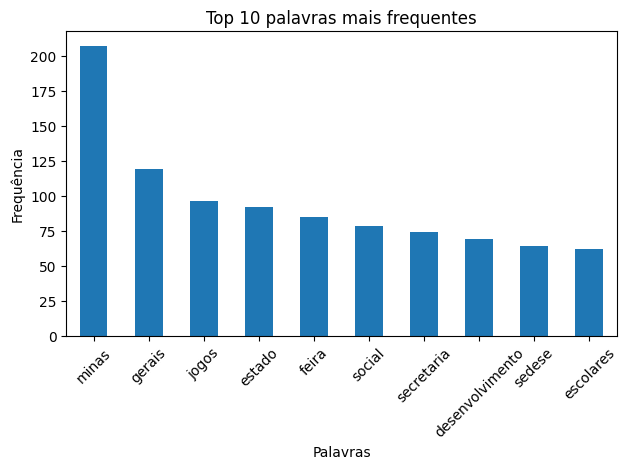

In [63]:
# gráfico das 10 palavras mais recentes 
import matplotlib.pyplot as plt

top10 = frequencia_palavras.head(10)
top10.index = top10.index.str.replace('bow_', '', regex=False)

plt.figure()
top10.plot(kind='bar')
plt.title('Top 10 palavras mais frequentes')
plt.xlabel('Palavras')
plt.ylabel('Frequência')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
frequencia_palavras.tail(10)

bow_visitarem    1
bow_virtude      1
bow_vindas       1
bow_video        1
bow_vicosa       1
bow_youtube      1
bow_yago         1
bow_xxvii        1
bow_xadrez       1
bow_willian      1
dtype: int64

In [65]:
documentos_por_palavra = (df_final[colunas_bow] > 0).sum().sort_values(ascending=False)
documentos_por_palavra.index = documentos_por_palavra.index.str.replace("bow_", "", regex=False)

documentos_por_palavra.head(10)

minas              181
gerais             116
jogos               94
estado              89
feira               84
social              78
secretaria          74
desenvolvimento     67
sedese              61
escolares           61
dtype: int64

In [66]:
df_final["palavras_unicas"] = (df_final[colunas_bow] > 0).sum(axis=1)

df_final[["titulo", "palavras_unicas"]].sort_values("palavras_unicas", ascending=True).head(10)

,titulo,palavras_unicas
300,Oficinas de esportes paralímpicos mobilizam cr...,9
134,"Etapa Estadual do Jemg reúne 6,4 mil estudante...",9
137,Mineirinho vira o palco do Arraial de Belô pel...,10
119,Prorrogado prazo para municípios que querem se...,10
132,Sedese realiza terceira edição da Semana do Co...,10
208,Governo do Estado inaugura Centro Mineiro de E...,10
178,Governo de Minas apresenta ações esportivas e ...,10
161,"Vitória Miranda, atleta patrocinada pela Copas...",10
209,Prorrogadas inscrições para o JimiVirtual até ...,10
184,Fórum de Temáticas Esportivas completa ciclo d...,10


# Título

In [67]:
from nltk.tokenize import wordpunct_tokenize
from unidecode import unidecode


def limpar_titulo(titulo):
    titulo = titulo.lower()
    titulo = unidecode(titulo)
    tokens = wordpunct_tokenize(titulo)
    tokens = [token for token in tokens if token.isalnum()]
    return " ".join(tokens)


df["titulo_limpo"] = df["titulo"].apply(limpar_titulo)

df[["titulo", "titulo_limpo"]].head()

,titulo,titulo_limpo
0,Minas promove capacitação de clubes de futebol...,minas promove capacitacao de clubes de futebol...
1,Minas Gerais fecha primeiro bloco dos Jogos Es...,minas gerais fecha primeiro bloco dos jogos es...
2,Estudantes de BH vão carregar bandeiras de Bra...,estudantes de bh vao carregar bandeiras de bra...
3,Governo publica edital 2019 do programa Bolsa ...,governo publica edital 2019 do programa bolsa ...
4,Cruzeiro e Minas Arena assinam acordo mediado ...,cruzeiro e minas arena assinam acordo mediado ...


In [68]:
df["tokens_titulo"] = df["titulo_limpo"].apply(remover_stopwords)
df["titulo_sem_stopwords"] = df["tokens_titulo"].str.join(" ")

df[["titulo_limpo", "tokens_titulo", "titulo_sem_stopwords"]].head()

,titulo_limpo,tokens_titulo,titulo_sem_stopwords
0,minas promove capacitacao de clubes de futebol...,"[minas, promove, capacitacao, clubes, futebol,...",minas promove capacitacao clubes futebol proto...
1,minas gerais fecha primeiro bloco dos jogos es...,"[minas, gerais, fecha, primeiro, bloco, jogos,...",minas gerais fecha primeiro bloco jogos escola...
2,estudantes de bh vao carregar bandeiras de bra...,"[estudantes, bh, vao, carregar, bandeiras, bra...",estudantes bh vao carregar bandeiras brasil ar...
3,governo publica edital 2019 do programa bolsa ...,"[governo, publica, edital, 2019, programa, bol...",governo publica edital 2019 programa bolsa atl...
4,cruzeiro e minas arena assinam acordo mediado ...,"[cruzeiro, minas, arena, assinam, acordo, medi...",cruzeiro minas arena assinam acordo mediado go...


In [69]:
vectorizer_titulo = CountVectorizer()
matriz_bow_titulo = vectorizer_titulo.fit_transform(df["titulo_sem_stopwords"])

df_bow_titulo = pd.DataFrame(
    matriz_bow_titulo.toarray(),
    columns=vectorizer_titulo.get_feature_names_out()
)

df_bow_titulo.head()

,10,100,103,11,12,130,14,15,16,17,...,voltadas,voltado,voltados,voltara,votacao,vou,vulneravel,xadrez,xxvii,zona
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [70]:
colunas_num_titulo = [col for col in df_bow_titulo.columns if any(char.isdigit() for char in col)]
df_bow_titulo = df_bow_titulo.drop(columns=colunas_num_titulo)

print(f"{len(colunas_num_titulo)} colunas removidas")

47 colunas removidas


# Subtítulo

In [71]:
def limpar_texto(texto):
    """Limpa um texto: minúsculas, remove acentos, tokeniza e filtra alfanuméricos."""
    texto = str(texto).lower()
    texto = unidecode(texto)
    tokens = wordpunct_tokenize(texto)
    tokens = [token for token in tokens if token.isalnum()]
    return " ".join(tokens)

df["subtitulo_limpo"] = df["subtitulo"].apply(limpar_texto)
df[["subtitulo", "subtitulo_limpo"]].head()

,subtitulo,subtitulo_limpo
0,Fale Agora será apresentado em times femininos...,fale agora sera apresentado em times femininos...
1,"Competição acontece em Uberlândia, no Triângul...",competicao acontece em uberlandia no triangulo...
2,"Ao todo, 26 alunos da Escola Estadual Tomás Br...",ao todo 26 alunos da escola estadual tomas bra...
3,As inscrições terminam no próximo dia 12 de se...,as inscricoes terminam no proximo dia 12 de se...
4,Documento foi assinado na tarde desta sexta-fe...,documento foi assinado na tarde desta sexta fe...


In [72]:
df["tokens_subtitulo"] = df["subtitulo_limpo"].apply(remover_stopwords)
df["subtitulo_sem_stopwords"] = df["tokens_subtitulo"].str.join(" ")

df[["subtitulo_limpo", "tokens_subtitulo", "subtitulo_sem_stopwords"]].head()

,subtitulo_limpo,tokens_subtitulo,subtitulo_sem_stopwords
0,fale agora sera apresentado em times femininos...,"[fale, agora, apresentado, times, femininos, m...",fale agora apresentado times femininos masculi...
1,competicao acontece em uberlandia no triangulo...,"[competicao, acontece, uberlandia, triangulo, ...",competicao acontece uberlandia triangulo minei...
2,ao todo 26 alunos da escola estadual tomas bra...,"[todo, 26, alunos, escola, estadual, tomas, br...",todo 26 alunos escola estadual tomas brandao v...
3,as inscricoes terminam no proximo dia 12 de se...,"[inscricoes, terminam, proximo, dia, 12, setem...",inscricoes terminam proximo dia 12 setembro
4,documento foi assinado na tarde desta sexta fe...,"[documento, assinado, tarde, desta, sexta, fei...",documento assinado tarde desta sexta feira 28 ...


In [73]:
vectorizer_subtitulo = CountVectorizer()
matriz_bow_subtitulo = vectorizer_subtitulo.fit_transform(df["subtitulo_sem_stopwords"])

df_bow_subtitulo = pd.DataFrame(
    matriz_bow_subtitulo.toarray(),
    columns=vectorizer_subtitulo.get_feature_names_out()
)

df_bow_subtitulo.head()

,05,10,100,101,11,11h,12,121,12h,13,...,voltados,votacao,votos,warner,xadrez,xcc,yago,youtube,zema,zona
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [74]:
colunas_num_subtitulo = [col for col in df_bow_subtitulo.columns if any(char.isdigit() for char in col)]
df_bow_subtitulo = df_bow_subtitulo.drop(columns=colunas_num_subtitulo)

print(f"{len(colunas_num_subtitulo)} colunas removidas")

86 colunas removidas


# Teste

In [75]:
import ast


def extrair_temas(temas_str):
    """Converte string de lista em texto plano com os temas separados por espaço."""
    try:
        lista = ast.literal_eval(str(temas_str))
        return " ".join(lista)
    except Exception:
        return str(temas_str)


df["temas_texto"] = df["temas"].apply(extrair_temas)
df[["temas", "temas_texto"]].head()

,temas,temas_texto
0,"['Social', 'Esportes']",Social Esportes
1,"['Social', 'Esportes']",Social Esportes
2,"['Educação', 'Esportes']",Educação Esportes
3,"['Social', 'Esportes']",Social Esportes
4,['Esportes'],Esportes


In [76]:
df["temas_limpo"] = df["temas_texto"].apply(limpar_texto)
df["tokens_temas"] = df["temas_limpo"].apply(remover_stopwords)
df["temas_sem_stopwords"] = df["tokens_temas"].str.join(" ")

df[["temas_texto", "temas_limpo", "temas_sem_stopwords"]].head()

,temas_texto,temas_limpo,temas_sem_stopwords
0,Social Esportes,social esportes,social esportes
1,Social Esportes,social esportes,social esportes
2,Educação Esportes,educacao esportes,educacao esportes
3,Social Esportes,social esportes,social esportes
4,Esportes,esportes,esportes


In [77]:
vectorizer_temas = CountVectorizer()
matriz_bow_temas = vectorizer_temas.fit_transform(df["temas_sem_stopwords"])

df_bow_temas = pd.DataFrame(
    matriz_bow_temas.toarray(),
    columns=vectorizer_temas.get_feature_names_out()
)
df_bow_temas.head()

,ambiente,brumadinho,consciente,coronavirus,cultura,desenvolvimento,direitos,economico,educacao,esportes,...,humanos,infraestrutura,meio,minas,pesquisa,saude,seguranca,social,trabalho,turismo
0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [78]:
colunas_num_temas = [col for col in df_bow_temas.columns if any(char.isdigit() for char in col)]
df_bow_temas = df_bow_temas.drop(columns=colunas_num_temas)

print(f"{len(colunas_num_temas)} colunas removidas")

0 colunas removidas


# Final

In [79]:
metadados = df[[
    "titulo", "subtitulo", "descricao", "temas", "data", "ano_mes", "ano",
    "mes", "hora", "turno", "n_temas", "tamanho_texto", "n_palavras_titulo",
    "n_relacionadas", "url"
]].reset_index(drop=True)

bow_desc_pref  = df_bow.add_prefix("bow_desc_").reset_index(drop=True)
bow_tit_pref   = df_bow_titulo.add_prefix("bow_tit_").reset_index(drop=True)
bow_sub_pref   = df_bow_subtitulo.add_prefix("bow_sub_").reset_index(drop=True)
bow_tema_pref  = df_bow_temas.add_prefix("bow_tema_").reset_index(drop=True)

df_final_completo = pd.concat(
    [metadados, bow_desc_pref, bow_tit_pref, bow_sub_pref, bow_tema_pref],
    axis=1
)

df_final_completo.head()

,titulo,subtitulo,descricao,temas,data,ano_mes,ano,mes,hora,turno,...,bow_tema_humanos,bow_tema_infraestrutura,bow_tema_meio,bow_tema_minas,bow_tema_pesquisa,bow_tema_saude,bow_tema_seguranca,bow_tema_social,bow_tema_trabalho,bow_tema_turismo
0,Minas promove capacitação de clubes de futebol...,Fale Agora será apresentado em times femininos...,Em continuidade à propagação e divulgação do P...,"['Social', 'Esportes']",2024-04-27 12:20:00-03:00,2024-04,2024,4,12,Tarde,...,0,0,0,0,0,0,0,1,0,0
1,Minas Gerais fecha primeiro bloco dos Jogos Es...,"Competição acontece em Uberlândia, no Triângul...",A delegação de Minas Gerais encerrou o primeir...,"['Social', 'Esportes']",2025-10-14 15:20:00-03:00,2025-10,2025,10,15,Tarde,...,0,0,0,0,0,0,0,1,0,0
2,Estudantes de BH vão carregar bandeiras de Bra...,"Ao todo, 26 alunos da Escola Estadual Tomás Br...",Esta terça-feira (2/7) é de expectativa para 2...,"['Educação', 'Esportes']",2019-07-02 17:02:00-03:00,2019-07,2019,7,17,Tarde,...,0,0,0,0,0,0,0,0,0,0
3,Governo publica edital 2019 do programa Bolsa ...,As inscrições terminam no próximo dia 12 de se...,A Secretaria de Estado de Desenvolvimento Soci...,"['Social', 'Esportes']",2019-08-27 14:35:00-03:00,2019-08,2019,8,14,Tarde,...,0,0,0,0,0,0,0,1,0,0
4,Cruzeiro e Minas Arena assinam acordo mediado ...,Documento foi assinado na tarde desta sexta-fe...,O acordo comercial entre a Minas Arena e o Cru...,['Esportes'],2023-04-28 18:25:00-03:00,2023-04,2023,4,18,Noite,...,0,0,0,0,0,0,0,0,0,0


# Descritiva

## Título

In [85]:
colunas_bow_titulo = [coluna for coluna in df_final_completo.columns if coluna.startswith("bow_tit_")]

frequencia_palavras = df_final_completo[colunas_bow_titulo].sum().sort_values(ascending=False)

print(f"Total de palavras diferentes: {len(frequencia_palavras)}")

frequencia_palavras.head(10)

Total de palavras diferentes: 851


bow_tit_minas        143
bow_tit_jogos         77
bow_tit_governo       71
bow_tit_escolares     58
bow_tit_gerais        52
bow_tit_esporte       45
bow_tit_etapa         28
bow_tit_atletas       28
bow_tit_estado        27
bow_tit_estadual      26
dtype: int64

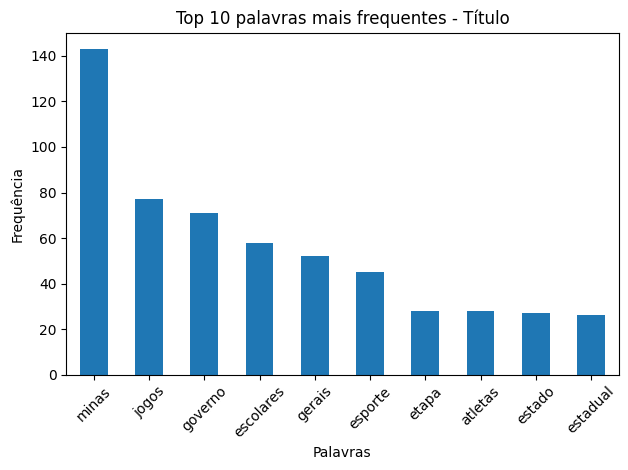

In [86]:
top10_titulo = frequencia_palavras.head(10)
top10_titulo.index = top10_titulo.index.str.replace('bow_tit_', '', regex=False)

import matplotlib.pyplot as plt

plt.figure()
top10_titulo.plot(kind='bar')

plt.title('Top 10 palavras mais frequentes - Título')
plt.xlabel('Palavras')
plt.ylabel('Frequência')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Subtítulo

In [87]:
colunas_bow_subtitulo = [coluna for coluna in df_final_completo.columns if coluna.startswith("bow_sub_")]

frequencia_palavras = df_final_completo[colunas_bow_subtitulo].sum().sort_values(ascending=False)

print(f"Total de palavras diferentes: {len(frequencia_palavras)}")

frequencia_palavras.head(10)

Total de palavras diferentes: 1332


bow_sub_minas         50
bow_sub_competicao    50
bow_sub_atletas       45
bow_sub_estado        41
bow_sub_municipios    41
bow_sub_esporte       30
bow_sub_evento        29
bow_sub_estudantes    27
bow_sub_mil           25
bow_sub_jogos         21
dtype: int64

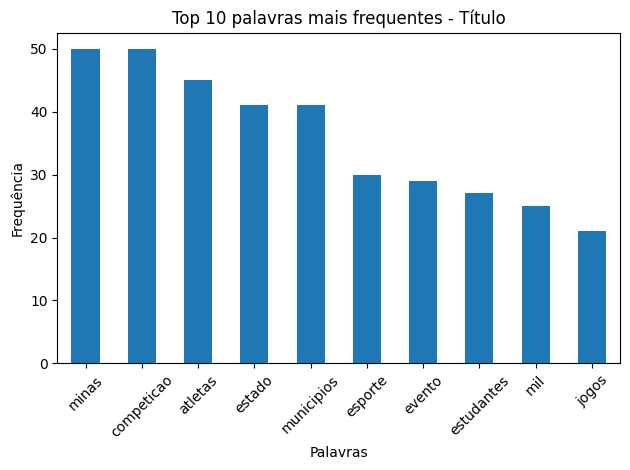

In [89]:
top10_subtitulo = frequencia_palavras.head(10)
top10_subtitulo.index = top10_subtitulo.index.str.replace('bow_sub_', '', regex=False)

import matplotlib.pyplot as plt

plt.figure()
top10_subtitulo.plot(kind='bar')

plt.title('Top 10 palavras mais frequentes - Subtítulo')
plt.xlabel('Palavras')
plt.ylabel('Frequência')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Temas

In [90]:
colunas_bow_tema = [coluna for coluna in df_final_completo.columns if coluna.startswith("bow_tema_")]

frequencia_palavras = df_final_completo[colunas_bow_tema].sum().sort_values(ascending=False)

print(f"Total de palavras diferentes: {len(frequencia_palavras)}")

frequencia_palavras.head(10)

Total de palavras diferentes: 23


bow_tema_esportes          323
bow_tema_social            176
bow_tema_educacao           77
bow_tema_infraestrutura     35
bow_tema_governo            33
bow_tema_cultura            22
bow_tema_governador         21
bow_tema_seguranca          14
bow_tema_turismo            14
bow_tema_humanos             9
dtype: int64

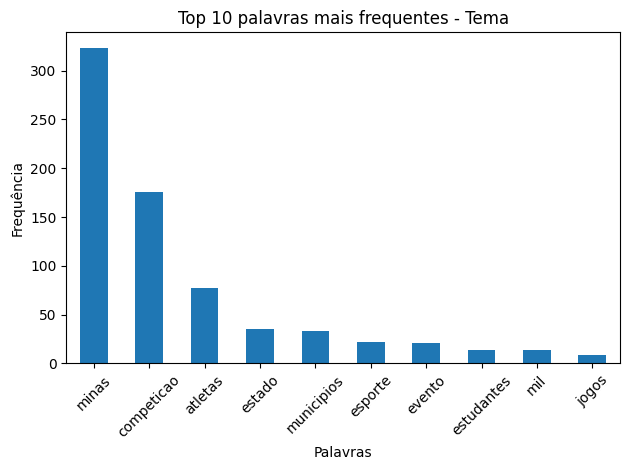

In [91]:
top10_tema = frequencia_palavras.head(10)
top10_tema.index = top10_subtitulo.index.str.replace('bow_tema_', '', regex=False)

import matplotlib.pyplot as plt

plt.figure()
top10_tema.plot(kind='bar')

plt.title('Top 10 palavras mais frequentes - Tema')
plt.xlabel('Palavras')
plt.ylabel('Frequência')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()